In [1]:
# 1. Download the stock data library
!pip install yfinance matplotlib numpy

# 2. Import them into our script
import yfinance as yf
import matplotlib.pyplot as plt

# 3. Pull historical data for the S&P 500 ETF (SPY)
df = yf.download("SPY", start="2021-01-01", end="2026-05-01")

# 4. View the top 5 rows of our new "Excel Sheet"
df.head()

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 10.5 MB/s  0:00:00

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ------------------------ --------------- 3/5 [curl_cffi]
   -------------------------------- ------- 4/5 [yfinance]
   -------------------------------- ------- 4/5 [yfinance]
   ---------------------------------------- 5/5 [yfinance]



[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
2021-01-04,343.319153,349.519177,339.623344,349.388832,110210800
2021-01-05,345.683685,346.772891,342.630223,342.676787,66426200
2021-01-06,347.750275,350.943399,343.626245,344.175493,107997700
2021-01-07,352.917053,353.661789,349.947372,350.124251,68766800
2021-01-08,354.927826,355.141923,351.055138,354.304088,71677200


In [2]:
df['Daily_Return'] = df['Close'].pct_change()
df.head(10)

Price,Close,High,Low,Open,Volume,Daily_Return
Ticker,SPY,SPY,SPY,SPY,SPY,
2021-01-04,343.319153,349.519177,339.623344,349.388832,110210800,NaN
2021-01-05,345.683685,346.772891,342.630223,342.676787,66426200,0.006887
2021-01-06,347.750275,350.943399,343.626245,344.175493,107997700,0.005978
2021-01-07,352.917053,353.661789,349.947372,350.124251,68766800,0.014858
2021-01-08,354.927826,355.141923,351.055138,354.304088,71677200,0.005698
2021-01-11,352.535400,354.294851,351.632393,351.753419,51034700,-0.006741
2021-01-12,352.609894,353.624609,350.366339,352.721630,52547700,0.000211
2021-01-13,353.559418,354.555495,351.753404,352.535385,45303600,0.002693
2021-01-14,352.321228,354.806834,351.986105,354.304122,49989100,-0.003502


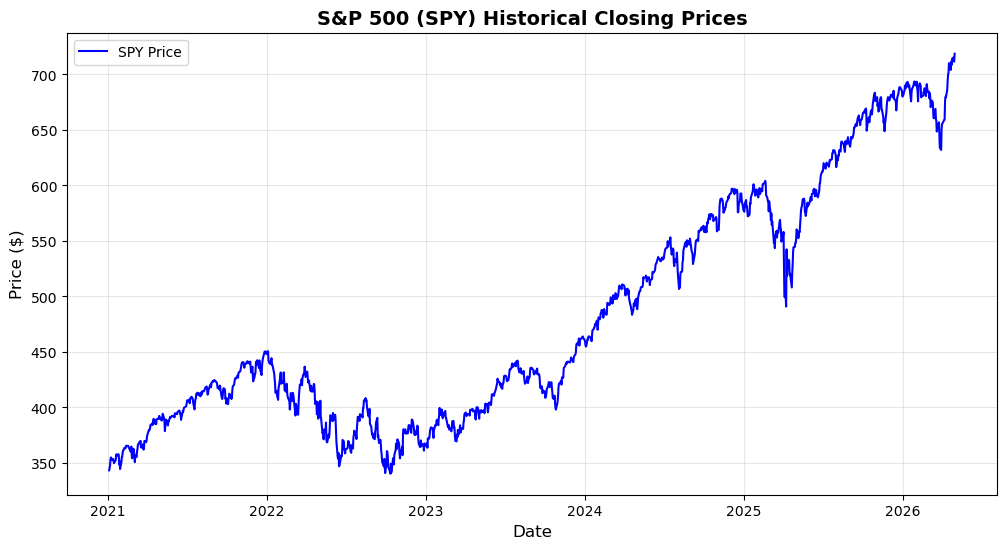

In [3]:
# Create a figure canvas that is 12 inches wide and 6 inches tall
plt.figure(figsize=(12, 6))

# Plot the daily closing prices with a blue line
plt.plot(df['Close'], color='blue', label='SPY Price')

# Add titles and labels so it looks professional
plt.title('S&P 500 (SPY) Historical Closing Prices', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)

# Turn on a clean background grid and a legend
plt.grid(True, alpha=0.3)
plt.legend()

# Display the chart on your screen
plt.show()


In [4]:
# Filter the spreadsheet to only include rows from Jan 1, 2022 to Dec 31, 2022
df_2022 = df.loc['2022-01-01':'2022-12-31']

# View the first 5 rows of this filtered data
df_2022.head()

Price,Close,High,Low,Open,Volume,Daily_Return
Ticker,SPY,SPY,SPY,SPY,SPY,
2022-01-03,450.644501,450.776583,447.003210,449.314383,72668200,0.005790
2022-01-04,450.493500,452.785845,448.635113,452.068895,71178700,-0.000335
2022-01-05,441.843018,450.899117,441.748678,450.125568,104538900,-0.019202
2022-01-06,441.427979,444.144811,439.060178,441.380823,86858900,-0.000939
2022-01-07,439.682800,442.616612,438.324384,441.437434,85111600,-0.003953


In [19]:
# Step 1: Define our filter condition (Daily Return less than -2%)
extreme_drop_condition = df['Daily_Return'] < -0.05

# Step 2: Feed that condition into our spreadsheet to extract the rows
crash_days = df[extreme_drop_condition]

# Step 3: Count how many times this happened and view the dates
print(f"Number of days SPY dropped more than 2%: {len(crash_days)}")
crash_days[['Close', 'Daily_Return']].head(43)

Number of days SPY dropped more than 2%: 1


Price,Close,Daily_Return
Ticker,SPY,
2025-04-04,499.553345,-0.058543


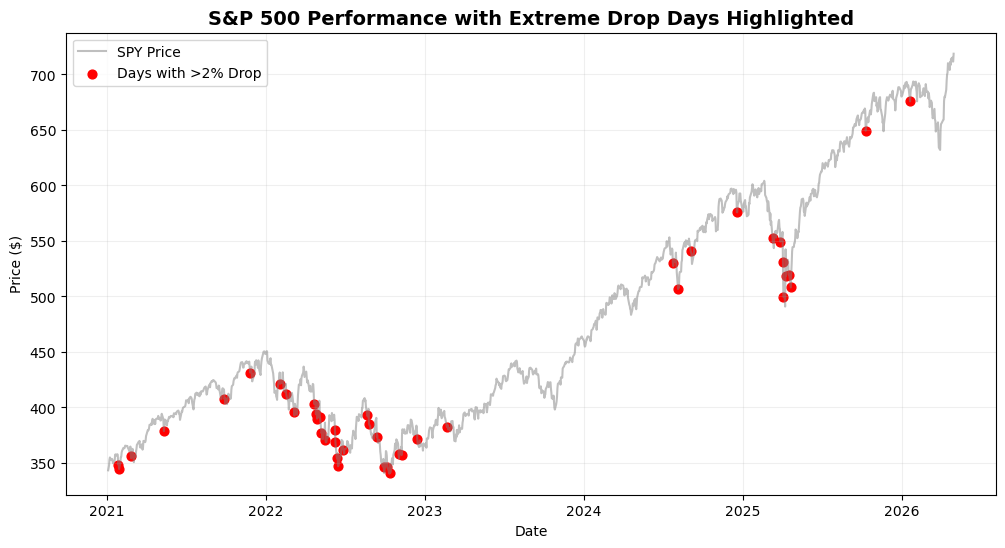

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# 1. Plot the continuous closing price line
plt.plot(df.index, df['Close'], color='gray', alpha=0.5, label='SPY Price')

# 2. Overlay our filtered "crash days" as bright red dots on top of the line
plt.scatter(crash_days.index, crash_days['Close'], color='red', s=40, label='Days with >2% Drop')

plt.title('S&P 500 Performance with Extreme Drop Days Highlighted', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [20]:
#1. Make sure the filter is set wide at 2%
extreme_drop_condition = df['Daily_Return'] < -0.02
crash_days = df[extreme_drop_condtion]

#2. Sort the table so the worst drops are at the veery top 
sorted_crashes = crash_days.sort_values(by=('Daily_Return', ''), ascending=True)

#3. View the top 10 worst days
sorted_crashes[['close', 'Daily_Return']].head(10)

NameError: name 'extreme_drop_condtion' is not defined

In [21]:
1 #1. Make sure the filter is set wide at 2%
      2 extreme_drop_condition = df['Daily_Return'] < -0.02 crash_days = df[extreme_drop_condtion]
      5 #2. Sort the table so the worst drops are at the veery top 
      6 sorted_crashes = crash_days.sort_values(by=('Daily_Return', ''), ascending=True)


IndentationError: unexpected indent (1642176421.py, line 2)

In [22]:
# 1. Make sure the filter is set wide at 2%
extreme_drop_condition = df['Daily_Return'] < -0.02
crash_days = df[extreme_drop_condition]

# 2. Sort the table so the worst drops are at the very top
sorted_crashes = crash_days.sort_values(by=('Daily_Return', ''), ascending=True)

# 3. View the top 10 worst days
sorted_crashes[['Close', 'Daily_Return']].head(10)

Price,Close,Daily_Return
Ticker,SPY,
2025-04-04,499.553345,-0.058543
2025-04-03,530.617310,-0.049281
2025-04-10,518.634644,-0.043819
2022-09-13,373.587036,-0.043482
2022-05-18,370.806763,-0.040312
2022-06-13,354.852661,-0.037968
2022-04-29,389.864777,-0.036956
2022-05-05,391.577545,-0.035543
2022-08-26,385.191010,-0.033849


In [23]:
extreme_drop_condition = df['Daily_Return'] < -0.02
crash_days = df[extreme_drop_condition]
sorted_crashes = crash_days.sort_values(by=('Daily_Retun', ''), ascending=True)
sorted_crashes[['Close', 'Daily_Return']].head(10)
    


KeyError: ('Daily_Retun', '')

In [24]:
extreme_drop_condition = df['Daily_Return'] < -0.02
crash_days = df[extreme_drop_condition]

sorted_crashes = crash_days.sort_values(by=('Daily_Retun', ''), ascending=True)

sorted_crashes[['Close', 'Daily_Return']].head(10)

KeyError: ('Daily_Retun', '')

In [31]:
#1. Make sure the filter is set wide at 2%
extreme_drop_condition = df['Daily_Return'] < -0.02
crash_days = df[extreme_drop_condition]

#2. sort the table so the worst drops at the very top
sorted_crashes = crash_days.sort_values(by=('Daily_Return', ''), ascending=True)

#3. View the top 10 worst days
sorted_crashes[['Close', 'Daily_Return']].head(43)

Price,Close,Daily_Return
Ticker,SPY,
2025-04-04,499.553345,-0.058543
2025-04-03,530.617310,-0.049281
2025-04-10,518.634644,-0.043819
2022-09-13,373.587036,-0.043482
2022-05-18,370.806763,-0.040312
2022-06-13,354.852661,-0.037968
2022-04-29,389.864777,-0.036956
2022-05-05,391.577545,-0.035543
2022-08-26,385.191010,-0.033849


In [33]:
ticker_growth = "NVDA"
ticker_defensive = "WMT"

data_growth = yf.download(ticker_growth, start="2021-01-01, end="2026-05-01")
data_defensive = yf.download(ticker_defensive, start="2021-01-01", end="2026-05-01")

data_growth['Daily_Return'] = data_growth['Close'].pct_change()
data_defensive['Daily_Return'] = data_defensive['Close'].pct_change()

comparison_table = pd.DataFrame(index=crash_days.index)

Comparison_table['S&P 500 (Market)'] = crash_days['Daily_Return']
comparison_table[f'{ticker_growth} (Growth)'] = data_growth['Daily_Return'].loc[crash_days.index]
comparison_table[f'{ticker_defensive} (Defensive)'] = data_defensive]['Daily_Return'].loc[crash_days.index]

comaprision_table

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (3669521680.py, line 4)

In [35]:
ticker_growth = "NVDA"
ticker_defensive = "WMT"

data_growth = yf.download(ticker_growth, start="2021-01-01", end="2026-05-01")
data_defensive = yf.download(ticker_defensive, start="2021-01-01", end="2026-05-01")

data_growth['Daily_Return'] = data_growth['Close'].pct_change()
data_defensive['Daily_Return'] = data_defensive['Close'].pct_change()

comparison_table = pd.DataFrame(index=crash_days.index)

Comparison_table['S&P 500 (Market)'] = crash_days['Daily_Return']
comparison_table[f'{ticker_growth} (Growth)'] = data_growth['Daily_Return'].loc[crash_days.index]
comparison_table[f'{ticker_defensive} (Defensive)'] = data_defensive]['Daily_Return'].loc[crash_days.index]

comaprision_table

SyntaxError: unmatched ']' (2249293625.py, line 14)

In [37]:
ticker_growth = "NVDA"
ticker_defensive = "WMT"

data_growth = yf.download(ticker_growth, start="2021-01-01", end="2026-05-01")
data_defensive = yf.download(ticker_defensive, start="2021-01-01", end="2026-05-01")

data_growth['Daily_Return'] = data_growth['Close'].pct_change()
data_defensive['Daily_Return'] = data_defensive['Close'].pct_change()

comparison_table = pd.DataFrame(index=crash_days.index)

Comparison_table['S&P 500 (Market)'] = crash_days['Daily_Return']
comparison_table[f'{ticker_growth} (Growth)'] = data_growth['Daily_Return'].loc[crash_days.index]
comparison_table[f'{ticker_defensive} (Defensive)'] = data_defensive['Daily_Return'].loc[crash_days.index]

comaprision_table

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


NameError: name 'pd' is not defined

In [38]:
ticker_growth = "NVDA"
ticker_defensive = "WMT"

data_growth = yf.download(ticker_growth, start="2021-01-01", end="2026-05-01")
data_defensive = yf.download(ticker_defensive, start="2021-01-01", end="2026-05-01")

data_growth['Daily_Return'] = data_growth['Close'].pct_change()
data_defensive['Daily_Return'] = data_defensive['Close'].pct_change()

comparison_table = pd.DataFrame(index=crash_days.index)

Comparison_table['S&P 500 (Market)'] = crash_days['Daily_Return']
comparison_table[f'{ticker_growth} (Growth)'] = data_growth['Daily_Return'].loc[crash_days.index]
comparison_table[f'{ticker_defensive} (Defensive)'] = data_defensive['Daily_Return'].loc[crash_days.index]

comaprision_table

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


NameError: name 'pd' is not defined

In [39]:
import pandas as pd
import yfinance as yf

ticker_growth = "NVDA"
ticker_defensive = "WMT"

data_growth = yf.download(ticker_growth, start="2021-01-01", end="2026-05-01")
data_defensive = yf.download(ticker_defensive, start="2021-01-01", end="2026-05-01")

data_growth['Daily_Return'] = data_growth['Close'].pct_change()
data_defensive['Daily_Return'] = data_defensive['Close'].pct_change()

comparison_table = pd.DataFrame(index=crash_days.index)

Comparison_table['S&P 500 (Market)'] = crash_days['Daily_Return']
comparison_table[f'{ticker_growth} (Growth)'] = data_growth['Daily_Return'].loc[crash_days.index]
comparison_table[f'{ticker_defensive} (Defensive)'] = data_defensive['Daily_Return'].loc[crash_days.index]

comaprision_table

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


NameError: name 'Comparison_table' is not defined

In [40]:
import pandas as pd
import yfinance as yf

ticker_growth = "NVDA"
ticker_defensive = "WMT"

# Download data
data_growth = yf.download(ticker_growth, start="2021-01-01", end="2026-05-01")
data_defensive = yf.download(ticker_defensive, start="2021-01-01", end="2026-05-01")

# Calculate daily returns
data_growth['Daily_Return'] = data_growth['Close'].pct_change()
data_defensive['Daily_Return'] = data_defensive['Close'].pct_change()

# Create the comparison table
comparison_table = pd.DataFrame(index=crash_days.index)

# Pull the returns side-by-side
comparison_table['S&P 500 (Market)'] = crash_days['Daily_Return']
comparison_table[f'{ticker_growth} (Growth)'] = data_growth['Daily_Return'].loc[crash_days.index]
comparison_table[f'{ticker_defensive} (Defensive)'] = data_defensive['Daily_Return'].loc[crash_days.index]

# View the final result
comparison_table

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,S&P 500 (Market),NVDA (Growth),WMT (Defensive)
2021-01-27,-0.024441,-0.038518,-0.024880
2021-01-29,-0.020020,-0.004693,-0.022678
2021-02-25,-0.024096,-0.082178,-0.009459
2021-05-12,-0.021245,-0.038287,-0.025869
2021-09-28,-0.020152,-0.044367,-0.012303
2021-11-26,-0.022303,-0.035839,-0.011192
2022-02-03,-0.023505,-0.051264,0.000994
2022-02-17,-0.021361,-0.075591,0.040066
2022-03-07,-0.029479,-0.069062,-0.008052
2022-04-22,-0.027439,-0.033097,-0.018828


In [41]:
# Calculate the exact risk multiplier for both stocks across all crash days
comparison_table['NVDA_Multiplier'] = comparison_table['NVDA (Growth)'] / comparison_table['S&P 500 (Market)']
comparison_table['WMT_Multiplier'] = comparison_table['WMT (Defensive)'] / comparison_table['S&P 500 (Market)']

# View the updated table with the new multiplier columns
comparison_table[['S&P 500 (Market)', 'NVDA_Multiplier', 'WMT_Multiplier']]

,S&P 500 (Market),NVDA_Multiplier,WMT_Multiplier
2021-01-27,-0.024441,1.575988,1.017961
2021-01-29,-0.020020,0.234431,1.132802
2021-02-25,-0.024096,3.410482,0.392551
2021-05-12,-0.021245,1.802165,1.217636
2021-09-28,-0.020152,2.201646,0.610493
2021-11-26,-0.022303,1.606887,0.501802
2022-02-03,-0.023505,2.180969,-0.042296
2022-02-17,-0.021361,3.538702,-1.875629
2022-03-07,-0.029479,2.342739,0.273146
2022-04-22,-0.027439,1.206206,0.686164


In [42]:
print("=== SYSTEMIC CRASH ANALYSIS SUMMARY (43 DAYS) ===")
print("-" * 50)

# 1. Average performance during market shocks
print(f"Average S&P 500 Market Drop: {comparison_table['S&P 500 (Market)'].mean() * 100:.2f}%")
print(f"Average NVDA (Growth) Drop:  {comparison_table['NVDA (Growth)'].mean() * 100:.2f}%")
print(f"Average WMT (Defensive) Drop: {comparison_table['WMT (Defensive)'].mean() * 100:.2f}%")
print("-" * 50)

# 2. Overall Risk Multipliers (Beta relative to market shocks)
nvda_beta = comparison_table['NVDA (Growth)'].mean() / comparison_table['S&P 500 (Market)'].mean()
wmt_beta = comparison_table['WMT (Defensive)'].mean() / comparison_table['S&P 500 (Market)'].mean()

print(f"NVDA Systematic Shock Beta: {nvda_beta:.2f}x (Amplifier)")
print(f"WMT Systematic Shock Beta:  {wmt_beta:.2f}x (Buffer)")
print("-" * 50)

# 3. Safe Haven Percentage (How often did they beat the market or stay green?)
nvda_green_days = (comparison_table['NVDA (Growth)'] > 0).sum()
wmt_green_days = (comparison_table['WMT (Defensive)'] > 0).sum()

print(f"NVDA stayed GREEN on {nvda_green_days} out of 43 crash days ({(nvda_green_days/43)*100:.1f}%)")
print(f"WMT stayed GREEN on {wmt_green_days} out of 43 crash days ({(wmt_green_days/43)*100:.1f}%)")

=== SYSTEMIC CRASH ANALYSIS SUMMARY (43 DAYS) ===
--------------------------------------------------
Average S&P 500 Market Drop: -2.80%
Average NVDA (Growth) Drop:  -5.57%
Average WMT (Defensive) Drop: -1.29%
--------------------------------------------------
NVDA Systematic Shock Beta: 1.99x (Amplifier)
WMT Systematic Shock Beta:  0.46x (Buffer)
--------------------------------------------------
NVDA stayed GREEN on 0 out of 43 crash days (0.0%)
WMT stayed GREEN on 8 out of 43 crash days (18.6%)


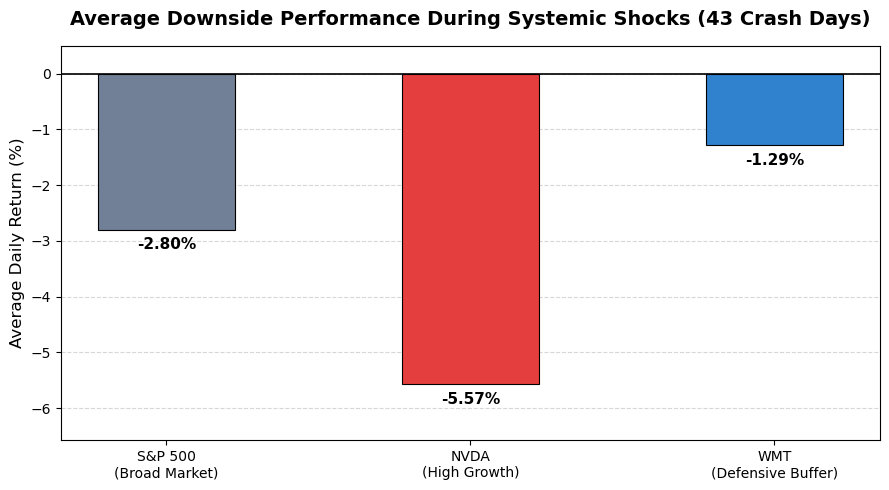

In [43]:
import matplotlib.pyplot as plt

# 1. Pull the average drops from your existing comparison table
avg_drops = [
    comparison_table['S&P 500 (Market)'].mean() * 100,
    comparison_table['NVDA (Growth)'].mean() * 100,
    comparison_table['WMT (Defensive)'].mean() * 100
]
labels = ['S&P 500\n(Broad Market)', 'NVDA\n(High Growth)', 'WMT\n(Defensive Buffer)']

# 2. Design the chart styling
# Using professional corporate colors: Neutral gray for market, Soft red for downside risk, Soft blue for safety
colors = ['#718096', '#E53E3E', '#3182CE'] 

plt.figure(figsize=(9, 5))
bars = plt.bar(labels, avg_drops, color=colors, width=0.45, edgecolor='black', linewidth=0.8, zorder=3)

# 3. Add clean styling and a background grid
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
plt.gca().set_axisbelow(True)

# 4. Add exact value labels below each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height - 0.4,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

# 5. Add titles, labels, and an elegant baseline at 0%
plt.title('Average Downside Performance During Systemic Shocks (43 Crash Days)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Average Daily Return (%)', fontsize=12)
plt.axhline(0, color='black', linewidth=1.2, zorder=2) 

# Adjust y-limits to leave room for the labels nicely
plt.ylim(min(avg_drops) - 1.0, 0.5)

# 6. Render the final layout
plt.tight_layout()
plt.show()

In [44]:
plt.savefig('systemic_crash_analysis.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [45]:
import os
print(os.getcwd())

C:\Users\Azizs\anaconda3


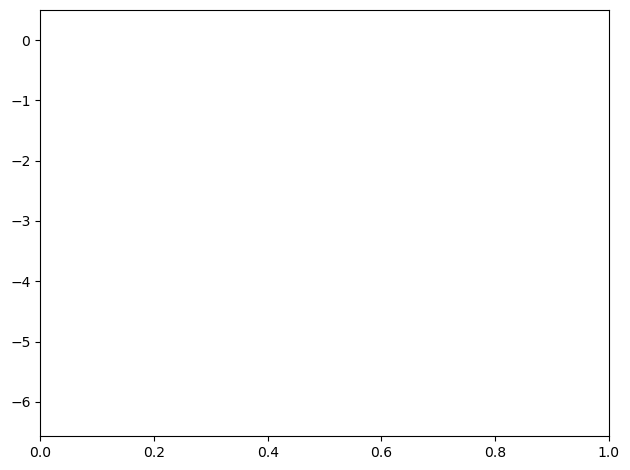

In [46]:
# Adjust y-limits to leave room for the labels nicely
plt.ylim(min(avg_drops) - 1.0, 0.5)

# === THE FIX: Save FIRST, then show ===
plt.savefig('systemic_crash_analysis.png', dpi=300, bbox_inches='tight')

# 6. Render the final layout to your screen
plt.tight_layout()
plt.show()

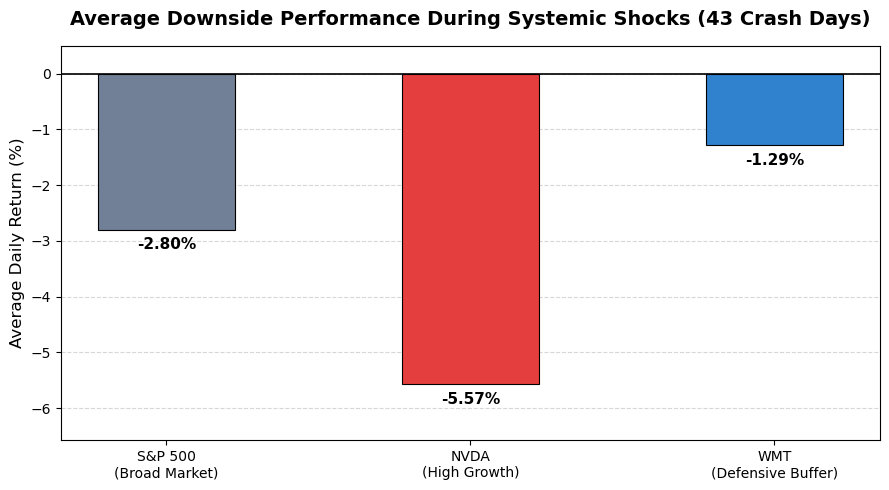

In [47]:
import matplotlib.pyplot as plt

# 1. COMPLETELY WIPE NOTEBOOK PLOT MEMORY
plt.clf()
plt.close('all')

# 2. Gather the data points
avg_drops = [
    comparison_table['S&P 500 (Market)'].mean() * 100,
    comparison_table['NVDA (Growth)'].mean() * 100,
    comparison_table['WMT (Defensive)'].mean() * 100
]
labels = ['S&P 500\n(Broad Market)', 'NVDA\n(High Growth)', 'WMT\n(Defensive Buffer)']
colors = ['#718096', '#E53E3E', '#3182CE'] 

# 3. Create the actual figure canvas
plt.figure(figsize=(9, 5))
bars = plt.bar(labels, avg_drops, color=colors, width=0.45, edgecolor='black', linewidth=0.8, zorder=3)

# 4. Design and styling
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
plt.gca().set_axisbelow(True)

# Add value labels below the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height - 0.4,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

plt.title('Average Downside Performance During Systemic Shocks (43 Crash Days)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Average Daily Return (%)', fontsize=12)
plt.axhline(0, color='black', linewidth=1.2, zorder=2) 
plt.ylim(min(avg_drops) - 1.0, 0.5)
plt.tight_layout()

# 5. === THE EXACT CRITICAL ORDER ===
# Save the figure to your folder FIRST
plt.savefig('systemic_crash_analysis.png', dpi=300, bbox_inches='tight')

# Show the figure on your screen SECOND
plt.show()